# Customer Churn Prediction — End-to-End Analysis

This notebook walks through the full workflow: problem framing, exploratory data
analysis (EDA), preprocessing, training and comparing three classifiers, and
interpreting the results.

**Goal:** predict whether a subscription customer will *churn* (leave) so the
business can intervene with retention offers before they do.

**Dataset:** the [Customer Churn dataset](https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset)
(training + testing CSVs).

> **Important data note.** The two shipped files do not come from the same
> distribution. Inside the *training* file the labels are near-deterministic
> (e.g. `Age > 50` or a `Monthly` contract ⇒ ~100% churn); in the *testing*
> file the same conditions churn only ~50–60% of the time. Using the testing
> file as a hold-out therefore measures **data drift**, not model quality. We
> evaluate on a stratified split of the training file (in-distribution) and use
> the testing file only as an *unseen scoring set* for the Power BI dashboard.

In [1]:
import sys
from pathlib import Path

# Make the project's src/ importable from the notebooks/ folder.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 1. Load the data

In [2]:
from data_preprocessing import load_raw, clean, FEATURES, NUMERIC_FEATURES, CATEGORICAL_FEATURES, TARGET

train_raw, test_raw = load_raw()
print('Training file:', train_raw.shape)
print('Testing file: ', test_raw.shape)
train_raw.head()

Training file: (440833, 12)
Testing file:  (64374, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [3]:
# Clean: drop the single empty trailing row and cast the target to int.
train = clean(train_raw)
print('Rows after cleaning:', len(train))
print('\nMissing values per column:')
print(train.isnull().sum())
print('\nChurn balance:')
print(train[TARGET].value_counts(normalize=True).rename({0: 'Retained', 1: 'Churned'}))

Rows after cleaning: 440832

Missing values per column:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

Churn balance:
Churn
Churned     0.567107
Retained    0.432893
Name: proportion, dtype: float64


## 2. Exploratory Data Analysis

We look at the overall churn balance and then at how churn varies with the
categorical and behavioural drivers.

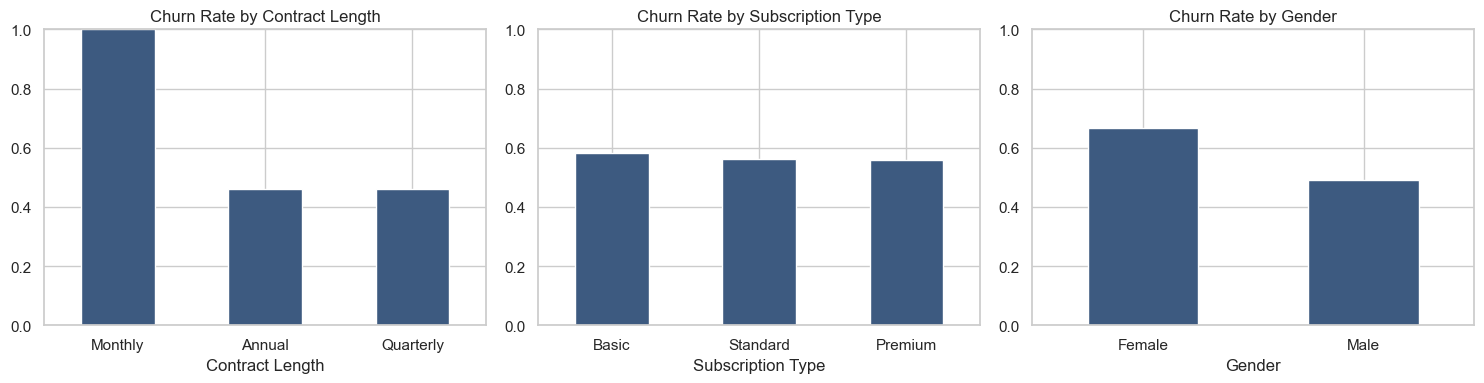

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Contract Length', 'Subscription Type', 'Gender']):
    rate = train.groupby(col)[TARGET].mean().sort_values(ascending=False)
    rate.plot(kind='bar', ax=ax, color='#3D5A80', rot=0)
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

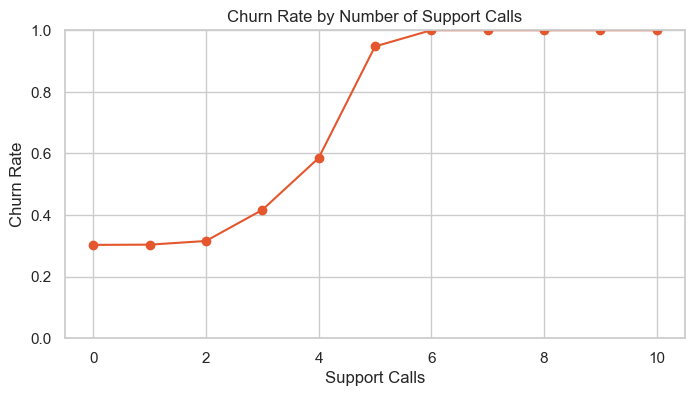

In [5]:
# Support calls are a strong behavioural signal for churn.
ax = train.groupby('Support Calls')[TARGET].mean().plot(marker='o', color='#E4572E', figsize=(8, 4))
ax.set_title('Churn Rate by Number of Support Calls'); ax.set_ylabel('Churn Rate'); ax.set_ylim(0, 1)
plt.show()

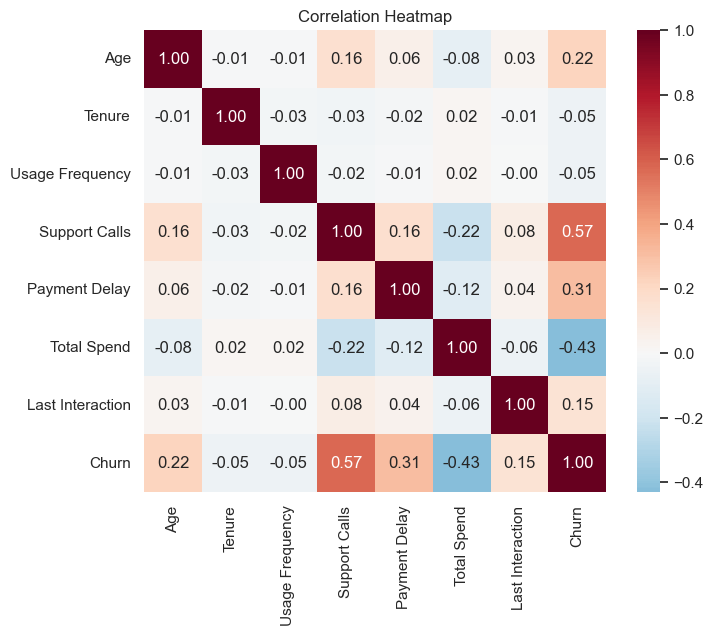

In [6]:
# Correlation between numeric features and churn.
plt.figure(figsize=(8, 6))
sns.heatmap(train[NUMERIC_FEATURES + [TARGET]].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Correlation Heatmap'); plt.show()

## 3. Preprocessing & train/validation split

Numeric features are standardised and categoricals one-hot encoded inside a
`ColumnTransformer`, all wrapped in a scikit-learn `Pipeline` so the transforms
are fit on the training fold only (no leakage). We evaluate on a stratified 80/20
split of the training file.

In [7]:
from data_preprocessing import load_clean_split

X_train, X_val, y_train, y_val = load_clean_split(test_size=0.2, random_state=42)
print('Train:', X_train.shape, '| Validation:', X_val.shape)

Train: (352665, 10) | Validation: (88167, 10)


## 4. Train & compare three models

In [8]:
from train_model import get_models, evaluate

rows = []
fitted = {}
for name, model in get_models().items():
    model.fit(X_train, y_train)
    metrics, y_pred, y_proba, roc = evaluate(name, model, X_val, y_val)
    rows.append(metrics)
    fitted[name] = model
    print(f"{name}: acc={metrics['Accuracy']:.3f}  f1={metrics['F1']:.3f}  auc={metrics['ROC_AUC']:.3f}")

results = pd.DataFrame(rows).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
results

Logistic Regression: acc=0.893  f1=0.904  auc=0.959


Random Forest: acc=0.999  f1=0.999  auc=1.000


Gradient Boosting: acc=1.000  f1=1.000  auc=1.000


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Gradient Boosting,0.999728,0.999880,0.99964,0.999760,1.000000
1,Random Forest,0.998945,0.999940,0.99820,0.999069,0.999999
2,Logistic Regression,0.893350,0.923388,0.88540,0.903995,0.959026


## 5. Best model — evaluation & interpretation

Best model: Gradient Boosting 

              precision    recall  f1-score   support

    Retained       1.00      1.00      1.00     38167
     Churned       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



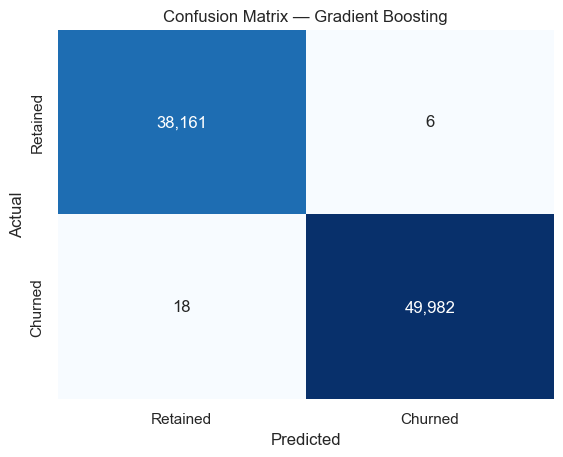

In [9]:
from sklearn.metrics import confusion_matrix, classification_report

best_name = results.iloc[0]['Model']
best_model = fitted[best_name]
y_pred = best_model.predict(X_val)
print('Best model:', best_name, '\n')
print(classification_report(y_val, y_pred, target_names=['Retained', 'Churned']))

cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False,
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
plt.title(f'Confusion Matrix — {best_name}'); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

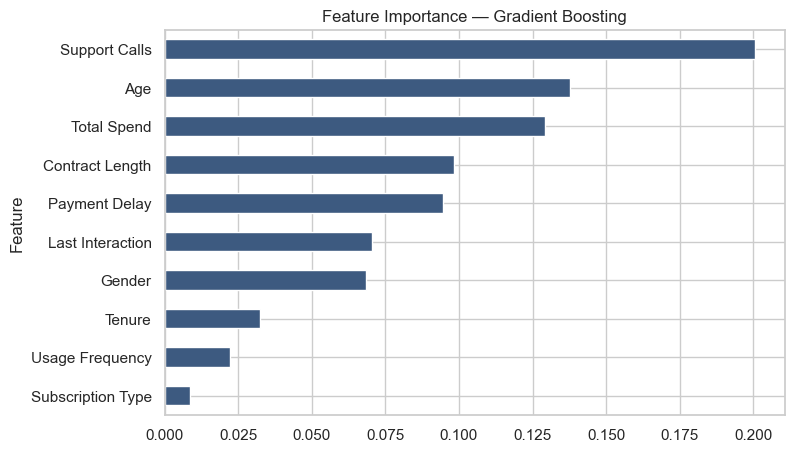

,Feature,Importance
0,Support Calls,0.20076
1,Age,0.13776
2,Total Spend,0.12940
3,Contract Length,0.09828
4,Payment Delay,0.09456
5,Last Interaction,0.07052
6,Gender,0.06832
7,Tenure,0.03244
8,Usage Frequency,0.02208
9,Subscription Type,0.00864


In [10]:
from train_model import feature_importance

imp = feature_importance(best_name, best_model, X_val, y_val)
ax = imp.sort_values('Importance').plot.barh(x='Feature', y='Importance', legend=False, color='#3D5A80', figsize=(8, 5))
ax.set_title(f'Feature Importance — {best_name}'); plt.show()
imp

## 6. Key takeaways

- **Support Calls, Age and Total Spend** are the strongest churn drivers.
- Customers on **Monthly** contracts churn far more than Annual/Quarterly.
- Tree-based models (Gradient Boosting / Random Forest) capture the dataset's
  rule-like structure almost perfectly in-distribution; Logistic Regression is a
  strong, interpretable baseline.
- **Business action:** target high-`Support Calls`, high-`Payment Delay`,
  Monthly-contract customers with proactive retention offers.

Run `python src/train_model.py` to persist the best model and the scored
`data/powerbi_churn_ready.csv` used by the Power BI dashboard.